In [ ]:
from pathlib import Path
import datetime as dt

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
# load metadata

p = Path("/Users/drotto/src/jirp/data/ibutton/metadata/deployment_log.xlsx")
deployments = pd.read_excel(p, comment="#")
deployments

,sensor_id,transect_name,point_id,elevation,datetime_out,datetime_in,initial_height,final_height,surface,housing,stake,notes
0,R,takub,NaN,1185,2023-07-07 09:45:00,2023-07-11 15:18:00,50,46.0,snow,NaN,bamboo,NaN
1,P,takub,NaN,1173,2023-07-07 09:45:00,NaT,50,NaN,snow,NaN,bamboo,NaN
2,B,takub,NaN,1170,2023-07-07 09:45:00,NaT,50,NaN,snow,NaN,bamboo,NaN
3,K,takub,NaN,1161,2023-07-07 09:45:00,NaT,50,NaN,snow,NaN,bamboo,NaN
4,T,takub,NaN,1146,2023-07-07 09:45:00,2023-07-11 15:06:00,50,0.0,snow,NaN,bamboo,NaN
5,G,takub,NaN,1120,2023-07-07 09:45:00,2023-07-11 14:27:00,50,25.0,snow,NaN,bamboo,NaN
6,L,takub,NaN,1186,2023-07-08 14:20:00,2023-07-11 15:20:00,50,43.0,snow,NaN,bamboo,NaN


In [ ]:
# config

DEPLOY_DATE = '230707'

In [ ]:
# make list of files

dirname = Path("/Users/drotto/Documents/jirp23/data")
fnames = list(dirname.iterdir())
fnames = [f for f in fnames if f.glob(DEPLOY_DATE)]
ids = [f.stem.split('_')[0] for f in fnames]
print(fnames)
print(ids)

[PosixPath('/Users/drotto/Documents/jirp23/data/G_230707.csv'), PosixPath('/Users/drotto/Documents/jirp23/data/T_230707.csv'), PosixPath('/Users/drotto/Documents/jirp23/data/L_230707.csv'), PosixPath('/Users/drotto/Documents/jirp23/data/R_230707.csv')]
['G', 'T', 'L', 'R']


In [ ]:
files = []
for id, fname in zip(ids, fnames):
    d = pd.read_csv(fname, skiprows=15)
    d.columns = ['datetime', 'unit', 'T']
    d['datetime'] = pd.to_datetime(d['datetime'])
    d['sensor_id'] = id
    d = d.drop(columns=['unit'])
    files.append(d)
df = pd.concat(files, ignore_index=True)
df

,datetime,T,sensor_id
0,2023-07-06 10:02:00,18.5,G
1,2023-07-06 10:12:00,18.5,G
2,2023-07-06 10:22:00,18.0,G
3,2023-07-06 10:32:00,16.5,G
4,2023-07-06 10:42:00,15.0,G
...,...,...,...
2313,2023-07-10 16:27:00,23.5,R
2314,2023-07-10 16:37:00,22.0,R
2315,2023-07-10 16:47:00,20.5,R
2316,2023-07-10 16:57:00,20.0,R


In [ ]:
# filter deployments
#deployments = deployments[deployments.datetime_out.dt.date == pd.to_datetime(DEPLOY_DATE, format='%y%m%d')]
deployments = deployments.loc[deployments.transect_name == 'takub']
deployments

,sensor_id,transect_name,point_id,elevation,datetime_out,datetime_in,initial_height,final_height,surface,housing,stake,notes
0,R,takub,NaN,1185,2023-07-07 09:45:00,2023-07-11 15:18:00,50,46.0,snow,NaN,bamboo,NaN
1,P,takub,NaN,1173,2023-07-07 09:45:00,NaT,50,NaN,snow,NaN,bamboo,NaN
2,B,takub,NaN,1170,2023-07-07 09:45:00,NaT,50,NaN,snow,NaN,bamboo,NaN
3,K,takub,NaN,1161,2023-07-07 09:45:00,NaT,50,NaN,snow,NaN,bamboo,NaN
4,T,takub,NaN,1146,2023-07-07 09:45:00,2023-07-11 15:06:00,50,0.0,snow,NaN,bamboo,NaN
5,G,takub,NaN,1120,2023-07-07 09:45:00,2023-07-11 14:27:00,50,25.0,snow,NaN,bamboo,NaN
6,L,takub,NaN,1186,2023-07-08 14:20:00,2023-07-11 15:20:00,50,43.0,snow,NaN,bamboo,NaN


In [ ]:
# filter data with deployments
print(f"Initial nobs = {len(df)}")
groups = []
for id, group in df.groupby('sensor_id'):
    deployment = deployments.loc[deployments.sensor_id == id]
    group = group.loc[(group['datetime'] > deployment['datetime_out'].item()) & (group["datetime"] < deployment["datetime_in"].item())]
    groups.append(group)
df = pd.concat(groups, ignore_index=True)
print(f"Filtered nobs = {len(df)}")
df

Initial nobs = 2318
Filtered nobs = 1869


,datetime,T,sensor_id
0,2023-07-07 09:52:00,10.5,G
1,2023-07-07 10:02:00,11.0,G
2,2023-07-07 10:12:00,11.5,G
3,2023-07-07 10:22:00,11.0,G
4,2023-07-07 10:32:00,12.0,G
...,...,...,...
1864,2023-07-10 16:29:00,23.5,T
1865,2023-07-10 16:39:00,22.5,T
1866,2023-07-10 16:49:00,22.0,T
1867,2023-07-10 16:59:00,21.5,T


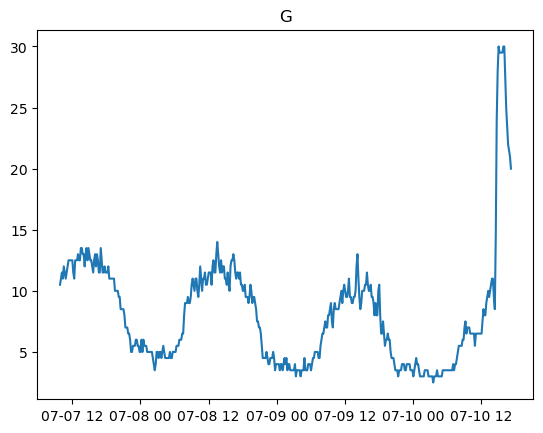

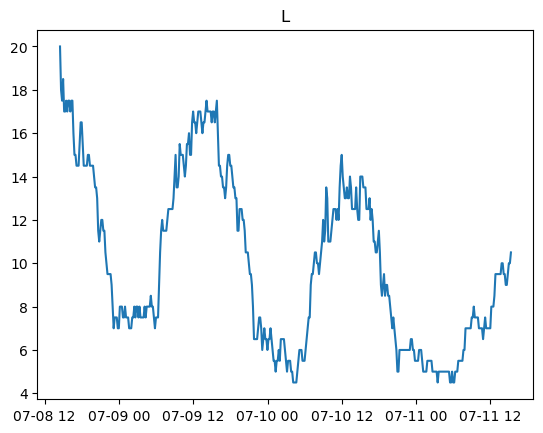

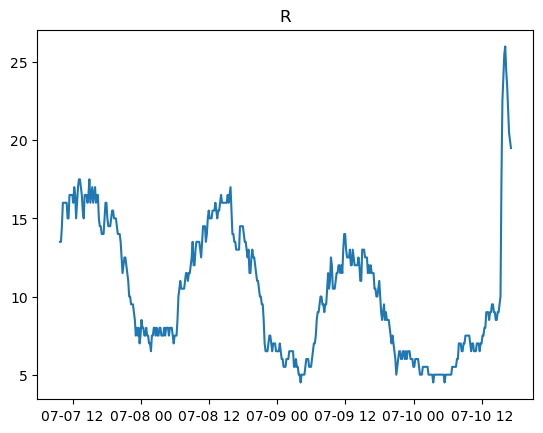

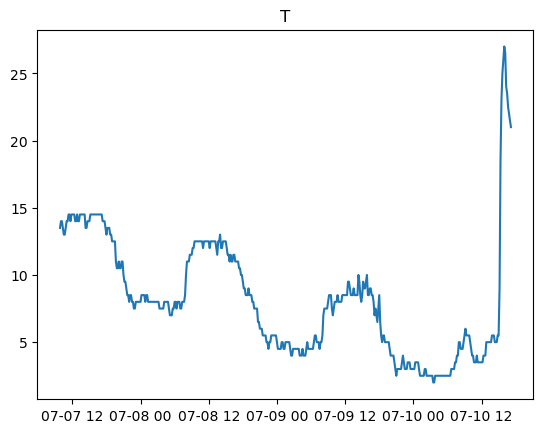

In [ ]:
# Look at the data, is it valid over the entire period?

DATA_MASK = {
    'G': (dt.datetime(2023, 7, 10, 11), None)
}

for id, group in df.groupby('sensor_id'):
    fig, ax = plt.subplots(1,1)
    ax.plot(group['datetime'], group['T'])
    ax.set_title(id)

In [ ]:
test = df.groupby('sensor_id').mean()
test = test.merge(deployments, on='sensor_id')
test

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_32952/3025339434.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  test = df.groupby('sensor_id').mean()


,sensor_id,T,transect_name,point_id,elevation,datetime_out,datetime_in,initial_height,final_height,surface,housing,stake,notes
0,G,8.115304,takub,NaN,1120,2023-07-07 09:45:00,2023-07-11 14:27:00,50,25.0,snow,NaN,bamboo,NaN
1,L,9.962329,takub,NaN,1186,2023-07-08 14:20:00,2023-07-11 15:20:00,50,43.0,snow,NaN,bamboo,NaN
2,R,10.337526,takub,NaN,1185,2023-07-07 09:45:00,2023-07-11 15:18:00,50,46.0,snow,NaN,bamboo,NaN
3,T,8.134172,takub,NaN,1146,2023-07-07 09:45:00,2023-07-11 15:06:00,50,0.0,snow,NaN,bamboo,NaN


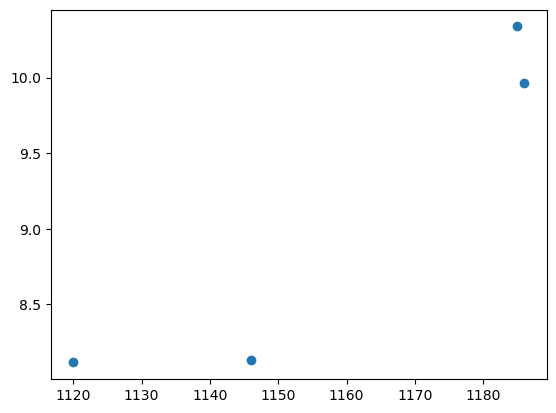

In [ ]:
fig, ax = plt.subplots(1,1)
ax.scatter(test['elevation'], test['T'])


In [ ]:
X = test['elevation'].to_numpy()
X = sm.add_constant(X)
y = test['T'].to_numpy()

res = sm.OLS(y, X).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     14.20
Date:                Tue, 11 Jul 2023   Prob (F-statistic):             0.0638
Time:                        22:15:22   Log-Likelihood:                -1.5768
No. Observations:                   4   AIC:                             7.154
Df Residuals:                       2   BIC:                             5.926
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -30.7112     10.579     -2.903      0.1

/Users/drotto/micromamba/envs/glacier-diseq/lib/python3.8/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
